In [3]:
!pip install transformers accelerate -q
!pip install openai-whisper -q
!pip install webrtcvad -q
!pip install soundfile librosa -q
!pip install Pillow requests -q


print("✓ Dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 15.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✓ Dependencies installed


In [10]:
import torch
import torch.nn.functional as F
import numpy as np
import whisper
import soundfile as sf
import librosa
import gc, os, tempfile, requests
from PIL import Image
from io import BytesIO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device: {device}")

✓ Device: cuda


Mounted at /content/drive
✓ Loaded from Drive : /content/drive/MyDrive/PFA/data/obama_yes_we_can.jpg
   Size   : (400, 300)
   Mode   : RGB


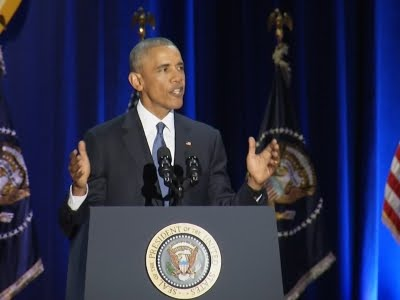

In [6]:
# ── CELL 3: Load test image — from upload or Drive ───────────────────────
# Option A: uploaded directly to Colab (files.upload())
# Option B: loaded from Google Drive path
# Uncomment whichever applies.

# ── Option A: Colab upload ────────────────────────────────────────────────
# from google.colab import files
# uploaded = files.upload()                        # triggers file picker
# fname = list(uploaded.keys())[0]
# test_image = Image.open(fname).convert("RGB")
# print(f"✓ Loaded uploaded file: {fname}")

# ── Option B: Google Drive ────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_IMAGE_PATH = "/content/drive/MyDrive/PFA/data/obama_yes_we_can.jpg"  # ← change as needed
test_image = Image.open(DRIVE_IMAGE_PATH).convert("RGB")
print(f"✓ Loaded from Drive : {DRIVE_IMAGE_PATH}")

# ── Shared: inspect ───────────────────────────────────────────────────────
print(f"   Size   : {test_image.size}")
print(f"   Mode   : {test_image.mode}")
test_image   # renders inline in Colab

In [5]:
# Load BLIP-2
# Paper: Li et al., ICML 2023 — Bootstrapping Language-Image Pre-training
# We use the OPT-2.7B variant: lighter than FlanT5, runs on Colab free tier

from transformers import Blip2Processor, Blip2ForConditionalGeneration

BLIP2_MODEL = "Salesforce/blip2-opt-2.7b"

print(f"Loading BLIP-2 ({BLIP2_MODEL}) ...")
blip2_processor = Blip2Processor.from_pretrained(BLIP2_MODEL)
blip2_model     = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto"
)
blip2_model.eval()
print("✓ BLIP-2 loaded")

Loading BLIP-2 (Salesforce/blip2-opt-2.7b) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

✓ BLIP-2 loaded


## lasted 4 min ( once also lasted 6 min)

In [7]:
# ── CELL 4a: [OPTION A] Load BLIP-2 ──────────────────────────────────────

from transformers import Blip2Processor, Blip2ForConditionalGeneration

_VARIANT = "BLIP-2"
print(f"Loading {_VARIANT} ...")

blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model     = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    device_map="auto",
)
blip_model.eval()

def blip_caption(image: Image.Image, prompt: str = None) -> str:
    text = prompt or None
    inputs = blip_processor(
        images=image,
        text=text,
        return_tensors="pt"
    ).to(device, torch.float16 if device == "cuda" else torch.float32)
    with torch.no_grad():
        ids = blip_model.generate(
            **inputs, max_new_tokens=50, num_beams=5, repetition_penalty=1.2
        )
    return blip_processor.batch_decode(ids, skip_special_tokens=True)[0].strip()

print(f"✓ {_VARIANT} ready  →  blip_model / blip_processor / blip_caption()")

Loading BLIP-2 ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


✓ BLIP-2 ready  →  blip_model / blip_processor / blip_caption()


In [ ]:
# ── CELL 4b: [OPTION B] Load BLIP-1 ──────────────────────────────────────
# Run this cell OR 4a — not both.
# Identical variable names — all downstream cells are unaffected.

from transformers import BlipProcessor, BlipForConditionalGeneration

_VARIANT = "BLIP-1"
print(f"Loading {_VARIANT} ...")

blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
blip_model     = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
).to(device)
blip_model.eval()

def blip_caption(image: Image.Image, prompt: str = None) -> str:
    # BLIP-1 ignores prompt — kept in signature for drop-in compatibility
    inputs = blip_processor(
        images=image, return_tensors="pt"
    ).to(device, torch.float16 if device == "cuda" else torch.float32)
    with torch.no_grad():
        ids = blip_model.generate(
            **inputs, max_new_tokens=50, num_beams=5, repetition_penalty=1.2
        )
    return blip_processor.decode(ids[0], skip_special_tokens=True).strip()

print(f"✓ {_VARIANT} ready  →  blip_model / blip_processor / blip_caption()")

In [8]:
# ── CELL 5: Caption test — free-form + prompted ───────────────────────────
# Works identically whichever of 4a / 4b you ran.

c_free     = blip_caption(test_image)
c_prompted = blip_caption(
    test_image,
    prompt="Question: Describe what is happening in this scene. Answer:"
)

print(f"[{_VARIANT} free]     {c_free}")
print(f"[{_VARIANT} prompted] {c_prompted}")

[BLIP-2 free]     president barack obama delivers his farewell address at the university of chicago on january 10, 2017 in chicago, il
[BLIP-2 prompted] Question: Describe what is happening in this scene. Answer: The president of the united states, barack obama, is giving a speech


In [12]:
#Free model from RAM

del blip_processor
del blip_model

gc.collect()
torch.cuda.empty_cache()

print(f"✓ {_VARIANT} unloaded — GPU/RAM freed")

NameError: name 'blip_processor' is not defined

In [16]:
# ssafe free model

import gc

for _var in ["blip_model", "blip_processor"]:
    if _var in dir():
        exec(f"del {_var}")
        print(f"✓ {_var} deleted")
    else:
        print(f"  {_var} was not loaded — skipping")

gc.collect()
torch.cuda.empty_cache()

print("✓ RAM/GPU freed")

  blip_model was not loaded — skipping
  blip_processor was not loaded — skipping
✓ RAM/GPU freed
